# Diagnóstico de Síndrome dos Ovários Policísticos (SOP) com Machine Learning

**Tech Challenge — Fase 1 | FIAP POSTECH — IA para Devs**

---

## Contexto do problema

A **Síndrome dos Ovários Policísticos (SOP)** é um dos distúrbios endócrinos mais comuns em mulheres em idade reprodutiva, afetando entre 8% e 13% dessa população. A síndrome se caracteriza por menstruações irregulares, excesso de hormônios masculinos (andrógenos) e ovários com múltiplos folículos pequenos.

O diagnóstico precoce é fundamental: mulheres com SOP não tratada têm maior risco de diabetes tipo 2, doenças cardiovasculares e infertilidade. No entanto, o diagnóstico ainda é tardio em muitos casos, pois os sintomas são variados e muitas vezes confundidos com outras condições.

**Objetivo:** construir um modelo de Machine Learning capaz de classificar, a partir de dados clínicos e laboratoriais, se uma paciente tem ou não SOP. O modelo deve servir como **apoio ao diagnóstico médico** — o médico sempre tem a palavra final.

---

## Dataset

- **Fonte:** [Kaggle — PCOS Dataset](https://www.kaggle.com/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos)
- **Autor:** Prasoon Kottarathil (2020) — 10 hospitais de Kerala, Índia
- **Tamanho:** 541 pacientes, 44 variáveis clínicas
- **Target:** `PCOS (Y/N)` — 0 = sem SOP, 1 = com SOP

---

## Estrutura do notebook

1. Importação das bibliotecas
2. Carregamento e merge dos dados
3. Exploração dos dados (EDA)
4. Pré-processamento
5. **Feature Engineering** — criação e seleção de features
6. Modelagem (Regressão Logística, Árvore de Decisão, Random Forest, KNN)
7. Avaliação dos modelos
8. Explicabilidade (Feature Importance e SHAP)
9. Conclusão crítica

---
## 1. Importação das bibliotecas

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# Modelos
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neighbors       import KNeighborsClassifier

# Métricas de avaliação
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

# Explicabilidade
import shap

# Configurações visuais
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

# Semente global — garante reprodutibilidade em qualquer máquina
SEMENTE_ALEATORIA = 42

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


---
## 2. Carregamento dos dados

O dataset é composto por dois arquivos disponibilizados no Kaggle:

- **PCOS_data_without_infertility.xlsx** — dados clínicos completos (44 colunas, 541 pacientes)
- **PCOS_infertility.csv** — exames complementares com os mesmos pacientes

**Investigação sobre o merge:**  
Ambos os arquivos têm uma coluna `Patient File No.`, mas os valores não coincidem diretamente:
o Excel usa IDs `1–541` e o CSV usa IDs `10001–10541` (prefixo `10000`).

Antes de fazer o merge, verificamos se são de fato os mesmos pacientes comparando:
1. `Sl. No` idêntico linha a linha nos dois arquivos
2. `PCOS (Y/N)` idêntico em **100% das 541 linhas** — zero divergências
3. `AMH(ng/mL)` idêntico nos dois arquivos (diferença = 0.0000)

**Conclusão:** são os mesmos pacientes na mesma ordem. O prefixo `10000` foi adicionado ao CSV
na separação dos arquivos. Porém, ao verificar as colunas, constatamos que **todas as colunas
do CSV já existem no Excel com valores idênticos** — o CSV não acrescenta nenhuma feature nova.

Por isso, **utilizamos apenas o Excel** como fonte de dados, evitando um merge desnecessário.

In [2]:
caminho_excel = '../pcos_data/PCOS_data_without_infertility.xlsx'
caminho_csv   = '../pcos_data/PCOS_infertility.csv'

# Carregando os dois arquivos para verificação e documentação
dados_principal   = pd.read_excel(caminho_excel, sheet_name='Full_new')
dados_fertilidade = pd.read_csv(caminho_csv)

print(f'Excel: {dados_principal.shape[0]} pacientes, {dados_principal.shape[1]} colunas')
print(f'CSV:   {dados_fertilidade.shape[0]} pacientes, {dados_fertilidade.shape[1]} colunas')

# Verificando que o CSV não tem nenhuma coluna exclusiva
cols_exclusivas_csv = set(dados_fertilidade.columns) - set(dados_principal.columns) - {'Patient File No.', 'Sl. No'}
print(f'\nColunas exclusivas do CSV (não existem no Excel): {cols_exclusivas_csv or "nenhuma"}')

# Confirmando que os dados de AMH são idênticos (mesmos pacientes)
amh_excel = pd.to_numeric(dados_principal['AMH(ng/mL)'], errors='coerce')
amh_csv   = pd.to_numeric(dados_fertilidade['AMH(ng/mL)'], errors='coerce')
pares_validos = amh_excel.notna() & amh_csv.notna()
diferenca_max = (amh_excel[pares_validos] - amh_csv[pares_validos]).abs().max()
print(f'Diferença máxima AMH entre Excel e CSV: {diferenca_max:.4f} (0 = dados idênticos)')
print(f'\nConclusão: utilizando apenas o Excel — fonte completa e sem redundâncias.')

Excel: 541 pacientes, 45 colunas
CSV:   541 pacientes, 6 colunas

Colunas exclusivas do CSV (não existem no Excel): nenhuma
Diferença máxima AMH entre Excel e CSV: 0.0000 (0 = dados idênticos)

Conclusão: utilizando apenas o Excel — fonte completa e sem redundâncias.


In [3]:
# Usando apenas o Excel — dataset completo e sem redundâncias
dados = dados_principal.copy()

print(f'Dataset carregado: {dados.shape[0]} pacientes, {dados.shape[1]} colunas')
dados.head()

Dataset carregado: 541 pacientes, 45 colunas


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [4]:
# Removendo colunas que não servem para modelagem:
# - 'Sl. No': índice sequencial
# - 'Patient File No.': identificador da paciente, não é uma feature clínica
# - 'Unnamed: 44': coluna vazia gerada pelo Excel
colunas_para_remover = ['Sl. No', 'Patient File No.', 'Unnamed: 44']
colunas_existentes   = [c for c in colunas_para_remover if c in dados.columns]
dados = dados.drop(columns=colunas_existentes)

print(f'Dataset final: {dados.shape[0]} pacientes, {dados.shape[1]} colunas')

Dataset final: 541 pacientes, 42 colunas


In [5]:
# Corrigindo colunas com tipos mistos (valores 'a' por erro de digitação)
# pd.to_numeric converte strings inválidas para NaN; tratamos na próxima etapa
for nome_coluna in ['AMH(ng/mL)', 'II    beta-HCG(mIU/mL)']:
    if nome_coluna in dados.columns:
        qtd = dados[nome_coluna].apply(lambda v: isinstance(v, str)).sum()
        dados[nome_coluna] = pd.to_numeric(dados[nome_coluna], errors='coerce')
        print(f'  "{nome_coluna}": {qtd} valor(es) inválido(s) → NaN')

print('Limpeza de tipos concluída!')

  "AMH(ng/mL)": 1 valor(es) inválido(s) → NaN
  "II    beta-HCG(mIU/mL)": 1 valor(es) inválido(s) → NaN
Limpeza de tipos concluída!


---
## 3. Exploração dos dados (EDA)

In [6]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PCOS (Y/N)              541 non-null    int64  
 1    Age (yrs)              541 non-null    int64  
 2   Weight (Kg)             541 non-null    float64
 3   Height(Cm)              541 non-null    float64
 4   BMI                     541 non-null    float64
 5   Blood Group             541 non-null    int64  
 6   Pulse rate(bpm)         541 non-null    int64  
 7   RR (breaths/min)        541 non-null    int64  
 8   Hb(g/dl)                541 non-null    float64
 9   Cycle(R/I)              541 non-null    int64  
 10  Cycle length(days)      541 non-null    int64  
 11  Marraige Status (Yrs)   540 non-null    float64
 12  Pregnant(Y/N)           541 non-null    int64  
 13  No. of aborptions       541 non-null    int64  
 14    I   beta-HCG(mIU/mL)  541 non-null    float64
 15  

In [7]:
dados.describe().round(2)

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,...,541.00,540.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00
mean,0.33,31.43,59.64,156.48,24.31,13.80,73.25,19.24,11.16,2.56,...,0.49,0.51,0.25,114.66,76.93,6.13,6.64,15.02,15.45,8.48
std,0.47,5.41,11.03,6.03,4.06,1.84,4.43,1.69,0.87,0.90,...,0.50,0.50,0.43,7.38,5.57,4.23,4.44,3.57,3.32,2.17
min,0.00,20.00,31.00,137.00,12.42,11.00,13.00,16.00,8.50,2.00,...,0.00,0.00,0.00,12.00,8.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,28.00,52.00,152.00,21.64,13.00,72.00,18.00,10.50,2.00,...,0.00,0.00,0.00,110.00,70.00,3.00,3.00,13.00,13.00,7.00
50%,0.00,31.00,59.00,156.00,24.24,14.00,72.00,18.00,11.00,2.00,...,0.00,1.00,0.00,110.00,80.00,5.00,6.00,15.00,16.00,8.50
75%,1.00,35.00,65.00,160.00,26.63,15.00,74.00,20.00,11.70,4.00,...,1.00,1.00,0.00,120.00,80.00,9.00,10.00,18.00,18.00,9.80
max,1.00,48.00,108.00,180.00,38.90,18.00,82.00,28.00,14.80,5.00,...,1.00,1.00,1.00,140.00,100.00,22.00,20.00,24.00,24.00,18.00


Sem SOP (0): 364 pacientes (67.3%)
Com SOP (1): 177 pacientes (32.7%)


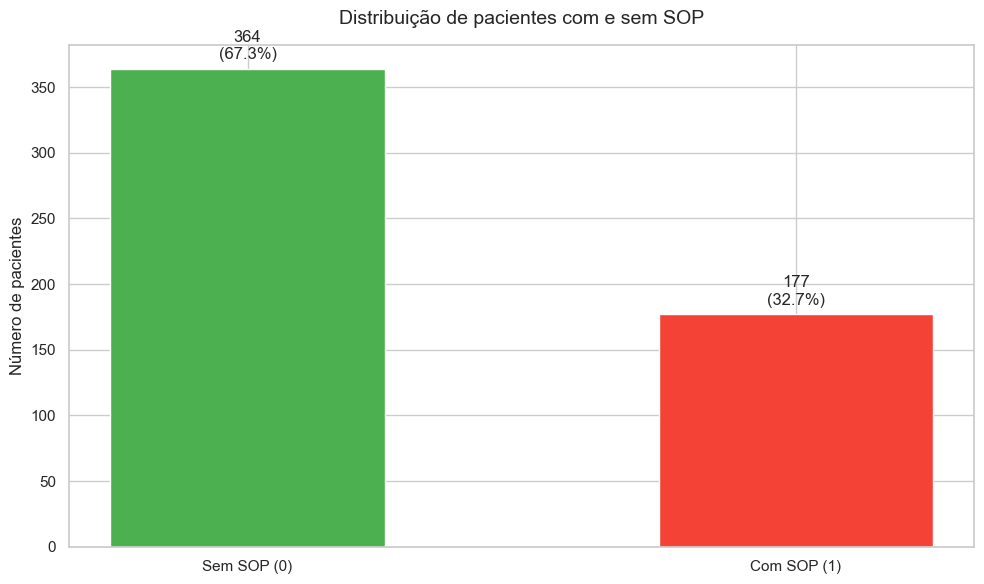

In [8]:
# Distribuição do target
contagem_target   = dados['PCOS (Y/N)'].value_counts()
percentual_target = dados['PCOS (Y/N)'].value_counts(normalize=True) * 100

print(f'Sem SOP (0): {contagem_target[0]} pacientes ({percentual_target[0]:.1f}%)')
print(f'Com SOP (1): {contagem_target[1]} pacientes ({percentual_target[1]:.1f}%)')

figura, eixo = plt.subplots()
eixo.bar(['Sem SOP (0)', 'Com SOP (1)'], contagem_target.values,
         color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)
eixo.set_title('Distribuição de pacientes com e sem SOP', fontsize=14, pad=15)
eixo.set_ylabel('Número de pacientes')
for i, v in enumerate(contagem_target.values):
    eixo.text(i, v + 5, f'{v}\n({percentual_target.values[i]:.1f}%)',
              ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('graficos/01_distribuicao_target.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.1 Distribuição das principais features clínicas

As features abaixo são os principais marcadores clínicos de SOP segundo a literatura:
- **AMH:** elevado na SOP (maior reserva ovariana)
- **FSH/LH:** razão reduzida é critério diagnóstico clássico
- **Contagem de folículos:** ≥12 por ovário é critério de Rotterdam
- **BMI:** obesidade agrava os sintomas de SOP

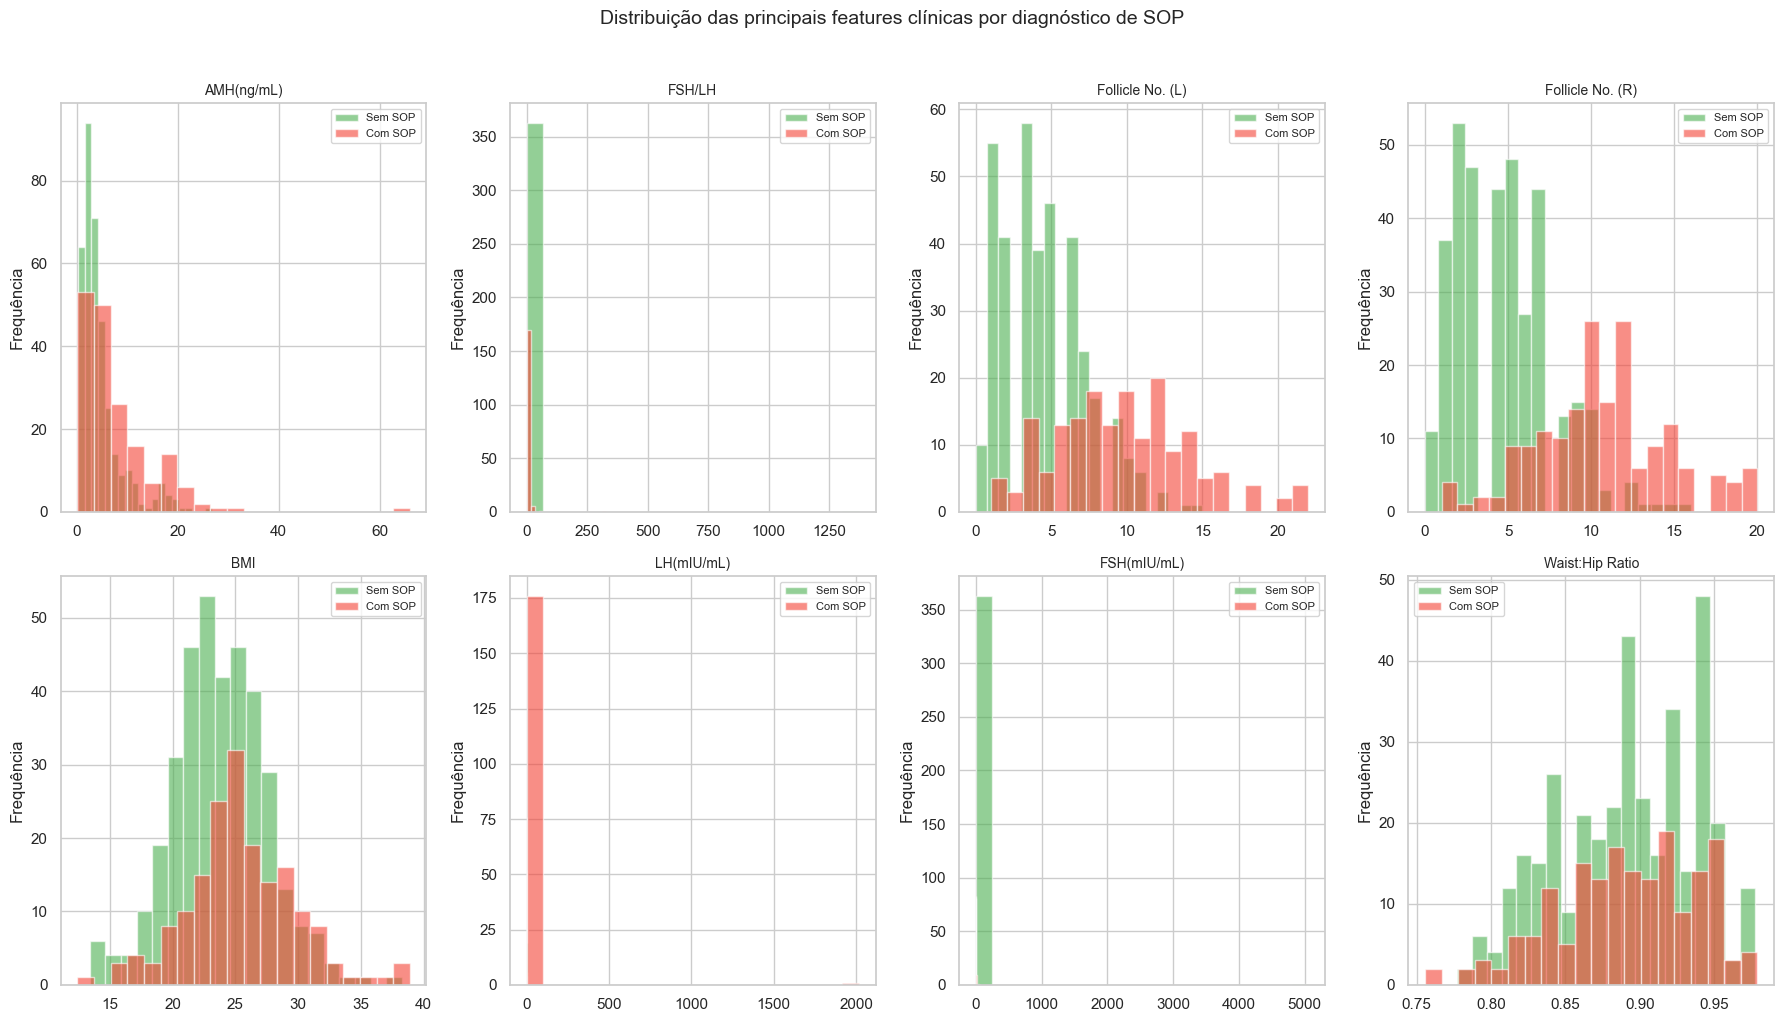

In [9]:
features_clinicas_importantes = [
    'AMH(ng/mL)', 'FSH/LH', 'Follicle No. (L)', 'Follicle No. (R)',
    'BMI', 'LH(mIU/mL)', 'FSH(mIU/mL)', 'Waist:Hip Ratio'
]

figura, eixos = plt.subplots(2, 4, figsize=(18, 10))
eixos = eixos.flatten()

for i, nome_feature in enumerate(features_clinicas_importantes):
    serie_sem_sop = pd.to_numeric(dados[dados['PCOS (Y/N)'] == 0][nome_feature], errors='coerce').dropna()
    serie_com_sop = pd.to_numeric(dados[dados['PCOS (Y/N)'] == 1][nome_feature], errors='coerce').dropna()
    eixos[i].hist(serie_sem_sop, bins=20, alpha=0.6, color='#4CAF50', label='Sem SOP')
    eixos[i].hist(serie_com_sop, bins=20, alpha=0.6, color='#F44336', label='Com SOP')
    eixos[i].set_title(nome_feature, fontsize=10)
    eixos[i].set_ylabel('Frequência')
    eixos[i].legend(fontsize=8)

figura.suptitle('Distribuição das principais features clínicas por diagnóstico de SOP',
                fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('graficos/02_distribuicao_features_clinicas.png', dpi=150, bbox_inches='tight')
plt.show()

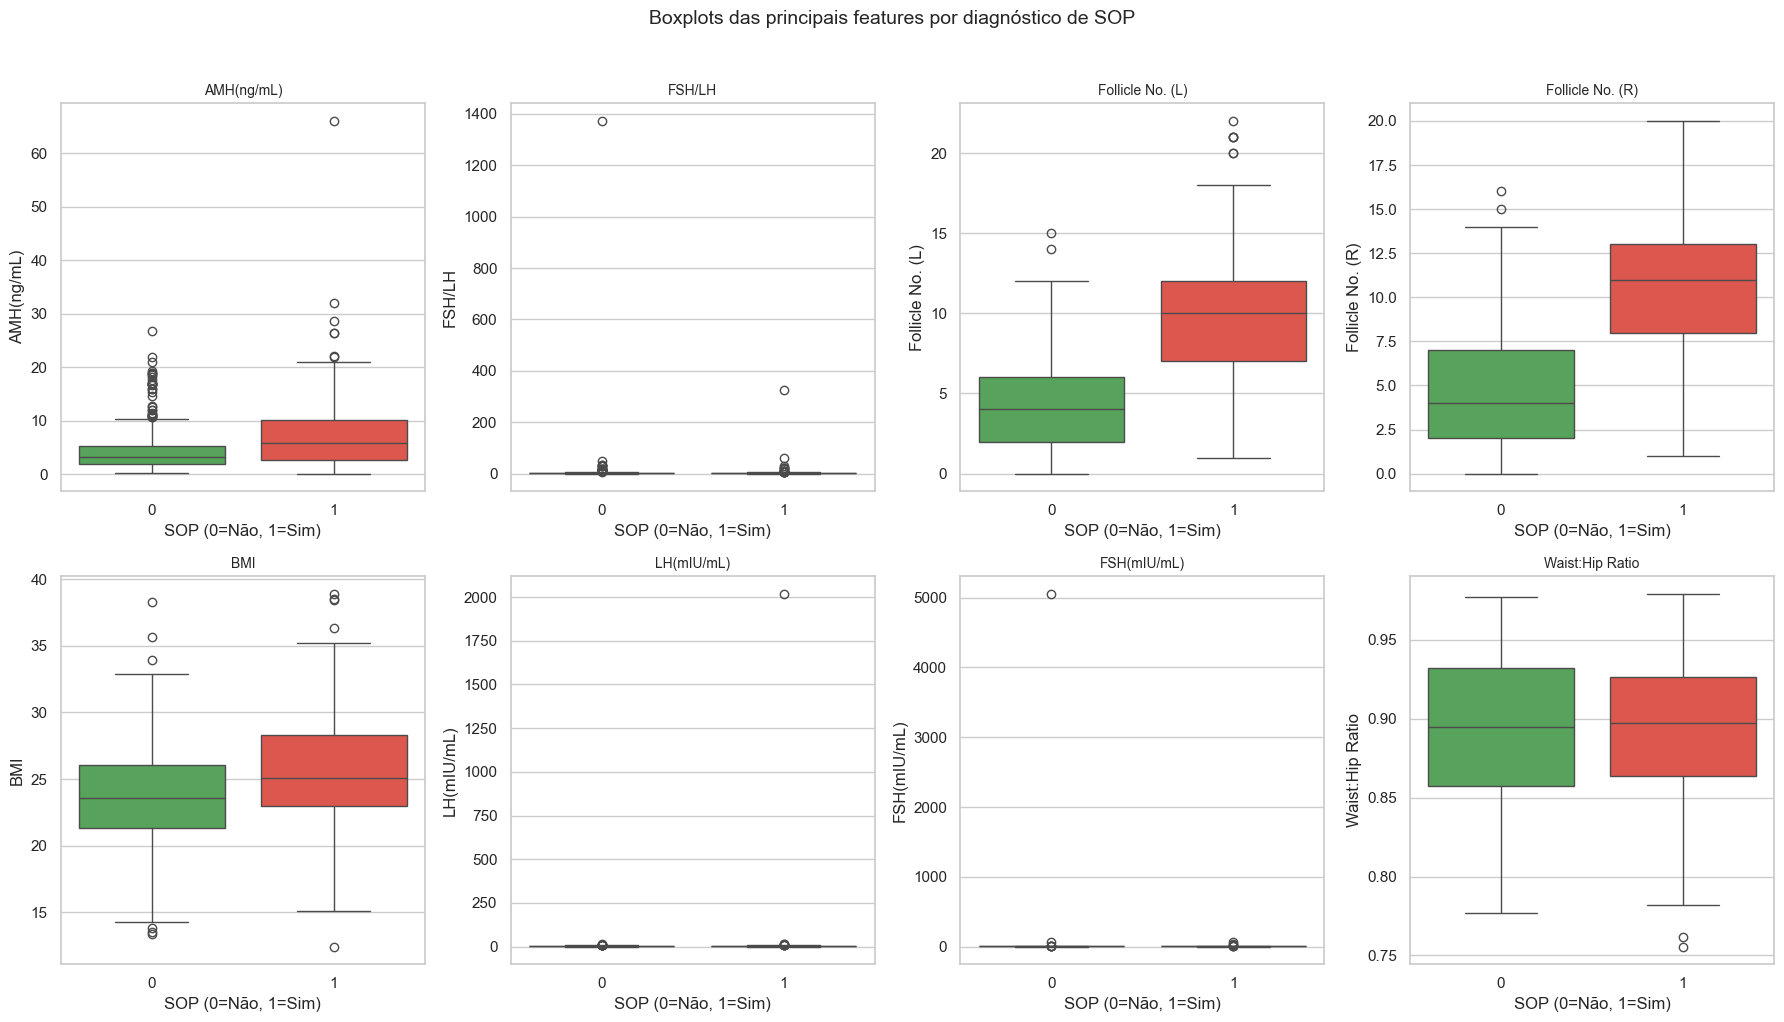

In [10]:
figura, eixos = plt.subplots(2, 4, figsize=(18, 10))
eixos = eixos.flatten()

for i, nome_feature in enumerate(features_clinicas_importantes):
    sns.boxplot(
        data=dados, x='PCOS (Y/N)', y=nome_feature,
        hue='PCOS (Y/N)', palette=['#4CAF50', '#F44336'],
        legend=False, ax=eixos[i]
    )
    eixos[i].set_title(nome_feature, fontsize=10)
    eixos[i].set_xlabel('SOP (0=Não, 1=Sim)')

figura.suptitle('Boxplots das principais features por diagnóstico de SOP', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('graficos/03_boxplots_features.png', dpi=150, bbox_inches='tight')
plt.show()

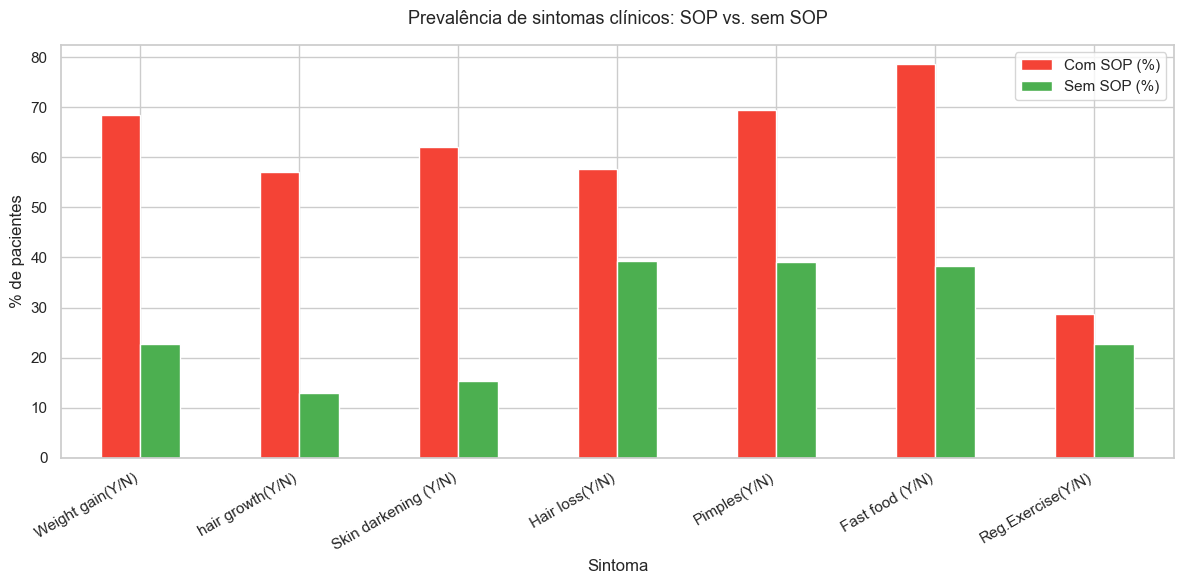

                      Com SOP (%)  Sem SOP (%)
Weight gain(Y/N)             68.4         22.8
hair growth(Y/N)             57.1         12.9
Skin darkening (Y/N)         62.1         15.4
Hair loss(Y/N)               57.6         39.3
Pimples(Y/N)                 69.5         39.0
Fast food (Y/N)              78.5         38.3
Reg.Exercise(Y/N)            28.8         22.8


In [11]:
sintomas_clinicos = [
    'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
    'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)'
]

proporcao_com_sop = dados[dados['PCOS (Y/N)'] == 1][sintomas_clinicos].mean() * 100
proporcao_sem_sop = dados[dados['PCOS (Y/N)'] == 0][sintomas_clinicos].mean() * 100

df_sintomas = pd.DataFrame({'Com SOP (%)': proporcao_com_sop, 'Sem SOP (%)': proporcao_sem_sop})
df_sintomas.plot(kind='bar', figsize=(12, 6), color=['#F44336', '#4CAF50'], edgecolor='white')
plt.title('Prevalência de sintomas clínicos: SOP vs. sem SOP', fontsize=13, pad=15)
plt.xlabel('Sintoma')
plt.ylabel('% de pacientes')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('graficos/04_prevalencia_sintomas.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_sintomas.round(1))

---
## 4. Pré-processamento

In [12]:
# Função reutilizável para preencher NaN com mediana
# Mediana é preferível à média em dados médicos — menos sensível a outliers
def preencher_ausentes_com_mediana(dataframe):
    colunas_num = dataframe.select_dtypes(include=[np.number]).columns
    total = 0
    for col in colunas_num:
        qtd = dataframe[col].isnull().sum()
        if qtd > 0:
            mediana = dataframe[col].median()
            dataframe[col] = dataframe[col].fillna(mediana)
            total += qtd
            print(f'  "{col}": {qtd} NaN → mediana = {mediana:.2f}')
    return total

total_preenchido = preencher_ausentes_com_mediana(dados)
print(f'\nTotal preenchido: {total_preenchido} | Ausentes restantes: {dados.isnull().sum().sum()}')

  "Marraige Status (Yrs)": 1 NaN → mediana = 7.00
  "II    beta-HCG(mIU/mL)": 1 NaN → mediana = 1.99
  "AMH(ng/mL)": 1 NaN → mediana = 3.70
  "Fast food (Y/N)": 1 NaN → mediana = 1.00

Total preenchido: 4 | Ausentes restantes: 0


In [13]:
# Blood Group é a única coluna textual — convertemos com LabelEncoder
# LabelEncoder atribui um inteiro para cada categoria (A+, A-, B+, etc.)
colunas_texto = dados.select_dtypes(include=['object', 'string']).columns.tolist()
print(f'Colunas de texto: {colunas_texto}')

codificador = LabelEncoder()
for col in colunas_texto:
    dados[col] = codificador.fit_transform(dados[col].astype(str))

# Segunda passada de imputação — garante zero NaN após todas as conversões
preencher_ausentes_com_mediana(dados)
print(f'Ausentes após conversão: {dados.isnull().sum().sum()}')

Colunas de texto: []
Ausentes após conversão: 0


---
## 5. Feature Engineering

Feature Engineering é a etapa em que criamos novas variáveis a partir das existentes, combinando conhecimento clínico com os padrões vistos na EDA. O objetivo é fornecer ao modelo informações mais diretas e expressivas do que as features brutas.

Nas aulas (ML Aula 2 — Correlação, ML Aula 3 — Redução de Dimensionalidade, MLA Aula 3 — Underfitting), o material cita Feature Engineering como uma das principais estratégias para melhorar modelos. Aplicamos aqui três abordagens:

1. **Criação de features derivadas** — combinações com significado clínico
2. **Feature Selection via correlação** — descartar variáveis com baixíssima relação com o target
3. **Comparação de desempenho** — verificar se as novas features melhoram os modelos

### 5.1 Criação de features derivadas

In [14]:
# ── Feature 1: total_foliculos ──────────────────────────────────────────────
# O critério de Rotterdam para SOP exige ≥ 12 folículos em pelo menos um ovário.
# Somando os dois lados damos ao modelo uma visão agregada diretamente
# ligada ao critério diagnóstico oficial.
dados['total_foliculos'] = dados['Follicle No. (L)'] + dados['Follicle No. (R)']

# ── Feature 2: soma_sintomas ─────────────────────────────────────────────────
# Pacientes com SOP tendem a acumular múltiplos sintomas ao mesmo tempo.
# Somar os sintomas binários cria um "índice de carga sintomática"
# que pode capturar esse padrão melhor do que variáveis isoladas.
colunas_sintomas = ['Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                    'Hair loss(Y/N)', 'Pimples(Y/N)']
dados['soma_sintomas'] = dados[colunas_sintomas].sum(axis=1)

# ── Feature 3: faixa_imc ─────────────────────────────────────────────────────
# O IMC bruto é contínuo — transformar em faixas clínicas (OMS) captura
# limiares que têm significado biológico real para SOP:
# 0=Abaixo do peso, 1=Normal, 2=Sobrepeso, 3=Obesidade, 4=Obesidade severa
limites_imc   = [0, 18.5, 24.9, 29.9, 34.9, 100]
rotulos_faixa = [0, 1, 2, 3, 4]
dados['faixa_imc'] = pd.cut(dados['BMI'], bins=limites_imc,
                             labels=rotulos_faixa, right=True).astype(float)

# ── Feature 4: razao_lh_fsh ──────────────────────────────────────────────────
# A razão LH/FSH > 2 é um marcador clínico estabelecido de SOP.
# O dataset já tem FSH/LH — criamos a razão inversa para deixar ambas disponíveis
# (valores altos = mais indicativo de SOP)
dados['razao_lh_fsh'] = dados['LH(mIU/mL)'] / (dados['FSH(mIU/mL)'] + 1e-6)

print('Features criadas:')
print(f"  total_foliculos  — mín: {dados['total_foliculos'].min():.0f}, "
      f"máx: {dados['total_foliculos'].max():.0f}, "
      f"média: {dados['total_foliculos'].mean():.1f}")
print(f"  soma_sintomas    — mín: {dados['soma_sintomas'].min():.0f}, "
      f"máx: {dados['soma_sintomas'].max():.0f}, "
      f"média: {dados['soma_sintomas'].mean():.1f}")
print(f"  faixa_imc        — distribuição:\n{dados['faixa_imc'].value_counts().sort_index()}")
print(f"  razao_lh_fsh     — mín: {dados['razao_lh_fsh'].min():.2f}, "
      f"máx: {dados['razao_lh_fsh'].max():.2f}, "
      f"média: {dados['razao_lh_fsh'].mean():.2f}")

Features criadas:
  total_foliculos  — mín: 1, máx: 41, média: 12.8
  soma_sintomas    — mín: 0, máx: 5, média: 1.9
  faixa_imc        — distribuição:
faixa_imc
0.0     36
1.0    272
2.0    190
3.0     36
4.0      7
Name: count, dtype: int64
  razao_lh_fsh     — mín: 0.00, máx: 466.05, média: 1.41


In [15]:
# Verificando a correlação das novas features com o target
novas_features = ['total_foliculos', 'soma_sintomas', 'faixa_imc', 'razao_lh_fsh']
correlacao_novas = dados[novas_features + ['PCOS (Y/N)']].corr()['PCOS (Y/N)'].drop('PCOS (Y/N)')

print('Correlação das novas features com PCOS (Y/N):')
for feat, corr in correlacao_novas.sort_values(ascending=False).items():
    print(f'  {feat:<20}: {corr:+.4f}')

# Comparando com as features originais equivalentes
print('\nComparação com features originais:')
comparacao = {
    'Follicle No. (L)':  dados['Follicle No. (L)'].corr(dados['PCOS (Y/N)']),
    'Follicle No. (R)':  dados['Follicle No. (R)'].corr(dados['PCOS (Y/N)']),
    'total_foliculos':   dados['total_foliculos'].corr(dados['PCOS (Y/N)']),
    'FSH/LH':            dados['FSH/LH'].corr(dados['PCOS (Y/N)']),
    'razao_lh_fsh':      dados['razao_lh_fsh'].corr(dados['PCOS (Y/N)']),
    'soma_sintomas':     dados['soma_sintomas'].corr(dados['PCOS (Y/N)']),
}
for feat, corr in comparacao.items():
    print(f'  {feat:<22}: {corr:+.4f}')

Correlação das novas features com PCOS (Y/N):
  total_foliculos     : +0.6603
  soma_sintomas       : +0.5802
  faixa_imc           : +0.1648
  razao_lh_fsh        : +0.0648

Comparação com features originais:
  Follicle No. (L)      : +0.6033
  Follicle No. (R)      : +0.6483
  total_foliculos       : +0.6603
  FSH/LH                : -0.0183
  razao_lh_fsh          : +0.0648
  soma_sintomas         : +0.5802


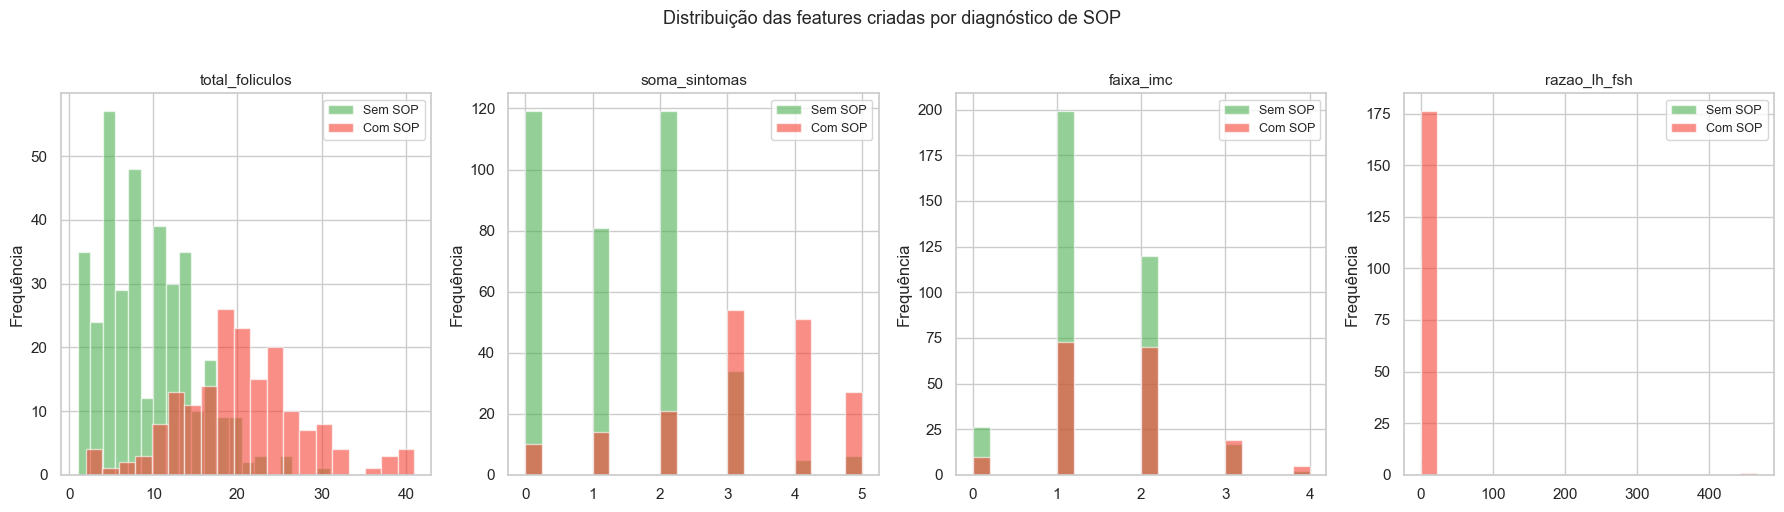

In [16]:
# Visualizando a distribuição das novas features por diagnóstico
figura, eixos = plt.subplots(1, 4, figsize=(18, 5))

for i, nome_feature in enumerate(novas_features):
    serie_sem_sop = dados[dados['PCOS (Y/N)'] == 0][nome_feature].dropna()
    serie_com_sop = dados[dados['PCOS (Y/N)'] == 1][nome_feature].dropna()
    eixos[i].hist(serie_sem_sop, bins=20, alpha=0.6, color='#4CAF50', label='Sem SOP')
    eixos[i].hist(serie_com_sop, bins=20, alpha=0.6, color='#F44336', label='Com SOP')
    eixos[i].set_title(nome_feature, fontsize=11)
    eixos[i].set_ylabel('Frequência')
    eixos[i].legend(fontsize=9)

figura.suptitle('Distribuição das features criadas por diagnóstico de SOP', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('graficos/fe_01_novas_features.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Feature Selection via correlação

Com base na **Aula 2 de ML** (correlação) e na **Feature Importance** da **Aula 4 de MLA**, descartamos features com correlação < 0.05 com o target e sem expressão no Random Forest. Isso reduz ruído e o risco de overfitting com variáveis irrelevantes.

In [17]:
# Calculando a correlação de TODAS as features (incluindo as novas) com o target
todas_correlacoes = dados.corr(numeric_only=True)['PCOS (Y/N)'].drop('PCOS (Y/N)')
correlacao_absoluta = todas_correlacoes.abs().sort_values(ascending=False)

print('Correlação com o target — todas as features:')
print(correlacao_absoluta.round(4).to_string())

Correlação com o target — todas as features:
total_foliculos           0.6603
Follicle No. (R)          0.6483
Follicle No. (L)          0.6033
soma_sintomas             0.5802
Skin darkening (Y/N)      0.4757
hair growth(Y/N)          0.4647
Weight gain(Y/N)          0.4410
Cycle(R/I)                0.4016
Fast food (Y/N)           0.3762
Pimples(Y/N)              0.2861
AMH(ng/mL)                0.2641
Weight (Kg)               0.2119
BMI                       0.1995
Cycle length(days)        0.1785
Hair loss(Y/N)            0.1729
 Age (yrs)                0.1685
faixa_imc                 0.1648
Waist(inch)               0.1646
Hip(inch)                 0.1623
Avg. F size (L) (mm)      0.1330
Marraige Status (Yrs)     0.1131
Endometrium (mm)          0.1066
Avg. F size (R) (mm)      0.0977
Pulse rate(bpm)           0.0918
Hb(g/dl)                  0.0872
Vit D3 (ng/mL)            0.0855
Height(Cm)                0.0683
Reg.Exercise(Y/N)         0.0653
razao_lh_fsh              0.064

In [18]:
# Features com correlação absoluta < 0.05 com o target são candidatas à remoção
# São variáveis que têm pouco poder discriminativo para SOP
LIMIAR_CORRELACAO = 0.05

features_baixa_correlacao = correlacao_absoluta[correlacao_absoluta < LIMIAR_CORRELACAO].index.tolist()

print(f'Features com |correlação| < {LIMIAR_CORRELACAO} (candidatas à remoção):')
for feat in features_baixa_correlacao:
    print(f'  {feat:<30}: {correlacao_absoluta[feat]:.4f}')

print(f'\nTotal: {len(features_baixa_correlacao)} features serão descartadas')

Features com |correlação| < 0.05 (candidatas à remoção):
  RBS(mg/dl)                    : 0.0489
  PRG(ng/mL)                    : 0.0438
  BP _Diastolic (mmHg)          : 0.0380
  RR (breaths/min)              : 0.0369
  Blood Group                   : 0.0364
  FSH(mIU/mL)                   : 0.0303
    I   beta-HCG(mIU/mL)        : 0.0276
  Pregnant(Y/N)                 : 0.0276
  FSH/LH                        : 0.0183
  II    beta-HCG(mIU/mL)        : 0.0128
  Waist:Hip Ratio               : 0.0124
  TSH (mIU/L)                   : 0.0101
  BP _Systolic (mmHg)           : 0.0079
  PRL(ng/mL)                    : 0.0051

Total: 14 features serão descartadas


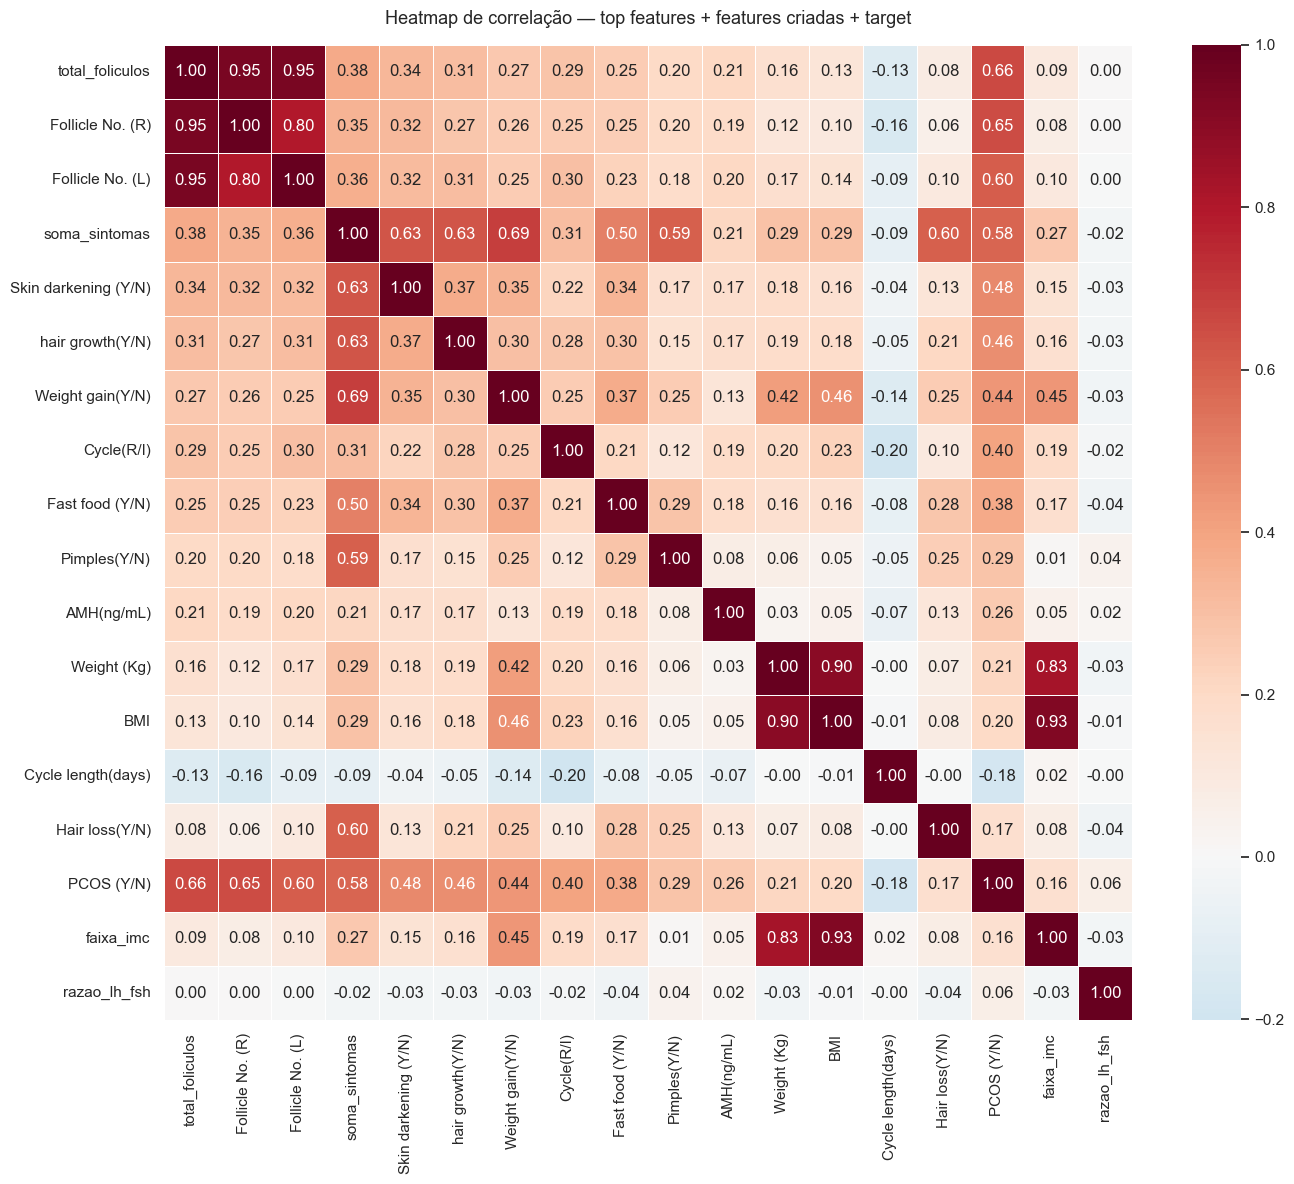

In [19]:
# Heatmap de correlação — top 15 features + novas + target
top_heatmap = list(correlacao_absoluta.head(15).index) + ['PCOS (Y/N)']
# Garantindo que as novas features estejam incluídas se estiverem no top
for nf in novas_features:
    if nf not in top_heatmap and nf in dados.columns:
        top_heatmap.append(nf)

figura, eixo = plt.subplots(figsize=(14, 12))
sns.heatmap(
    dados[top_heatmap].corr(),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    ax=eixo, linewidths=0.5
)
eixo.set_title('Heatmap de correlação — top features + features criadas + target',
               fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('graficos/05_heatmap_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Separação X / y e aplicação da Feature Selection

In [20]:
# Separando target (y) das features (X)
X_completo = dados.drop(columns=['PCOS (Y/N)'])
y          = dados['PCOS (Y/N)']

# Removendo features de baixa correlação com o target
X_selecionado = X_completo.drop(columns=features_baixa_correlacao, errors='ignore')

print(f'X original (todas as features):   {X_completo.shape[1]} features')
print(f'X selecionado (após filtro):       {X_selecionado.shape[1]} features')
print(f'Features removidas:                {len(features_baixa_correlacao)}')
print(f'\nFeatures que permanecem:')
print(sorted(X_selecionado.columns.tolist()))

X original (todas as features):   45 features
X selecionado (após filtro):       31 features
Features removidas:                14

Features que permanecem:
[' Age (yrs)', 'AMH(ng/mL)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'BMI', 'Cycle length(days)', 'Cycle(R/I)', 'Endometrium (mm)', 'Fast food (Y/N)', 'Follicle No. (L)', 'Follicle No. (R)', 'Hair loss(Y/N)', 'Hb(g/dl)', 'Height(Cm) ', 'Hip(inch)', 'LH(mIU/mL)', 'Marraige Status (Yrs)', 'No. of aborptions', 'Pimples(Y/N)', 'Pulse rate(bpm) ', 'Reg.Exercise(Y/N)', 'Skin darkening (Y/N)', 'Vit D3 (ng/mL)', 'Waist(inch)', 'Weight (Kg)', 'Weight gain(Y/N)', 'faixa_imc', 'hair growth(Y/N)', 'razao_lh_fsh', 'soma_sintomas', 'total_foliculos']


### 5.4 Separação treino/teste

Dividimos **80% para treino** e **20% para teste**, com `stratify=y` para manter a proporção SOP/não-SOP em ambos os conjuntos.

In [21]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_selecionado,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEMENTE_ALEATORIA
)

print(f'Treino: {X_treino.shape[0]} pacientes | Teste: {X_teste.shape[0]} pacientes')
print(f'Proporção SOP treino: {y_treino.mean()*100:.1f}% | teste: {y_teste.mean()*100:.1f}%')

Treino: 432 pacientes | Teste: 109 pacientes
Proporção SOP treino: 32.6% | teste: 33.0%


### 5.5 Normalização (StandardScaler)

Aplicamos z-score nas features. O `fit()` usa **apenas o treino** para calcular média e desvio padrão — o conjunto de teste é transformado com as estatísticas do treino para evitar *data leakage*.

Isso é especialmente importante para o **KNN**, que calcula distâncias entre pontos: sem normalização, features com escala maior dominariam o cálculo de distância.

In [22]:
normalizador = StandardScaler()
normalizador.fit(X_treino)

X_treino_norm = normalizador.transform(X_treino)
X_teste_norm  = normalizador.transform(X_teste)

print('StandardScaler aplicado com sucesso!')
print(f'Média no treino normalizado (esperado ~0): {X_treino_norm.mean():.6f}')
print(f'Desvio padrão no treino normalizado (~1):  {X_treino_norm.std():.6f}')

StandardScaler aplicado com sucesso!
Média no treino normalizado (esperado ~0): 0.000000
Desvio padrão no treino normalizado (~1):  1.000000


---
## 6. Modelagem

Treinamos **4 modelos** de classificação supervisionada.

| Modelo | Embasamento nas aulas | Por quê usar? |
|---|---|---|
| **Regressão Logística** | MLA Aula 1 | Baseline interpretável |
| **Árvore de Decisão** | MLA Aula 4 | Regras IF/ELSE, explicável para médicos |
| **Random Forest** | MLA Aula 4 | Robusto, fornece feature importance |
| **KNN** | MLA Aula 2 | Baseado em distância entre pacientes similares |

### Por que Recall é a métrica mais importante?

- **Falso Negativo** = modelo diz "sem SOP", mas paciente TEM SOP → não recebe tratamento → risco de diabetes, infertilidade
- **Falso Positivo** = modelo diz "com SOP", mas paciente não tem → faz mais exames → indesejável, mas menos grave

O **Recall** mede: de todas as pacientes COM SOP, quantas o modelo identificou corretamente?

### 6.1 Regressão Logística

In [23]:
# Regressão Logística — modelo linear que usa função sigmoide para classificar
# class_weight='balanced' aumenta o peso dos erros na classe minoritária (SOP)
modelo_regressao_logistica = LogisticRegression(
    random_state=SEMENTE_ALEATORIA,
    max_iter=1000,
    class_weight='balanced'
)
modelo_regressao_logistica.fit(X_treino_norm, y_treino)
previsoes_regressao_logistica = modelo_regressao_logistica.predict(X_teste_norm)
print('Regressão Logística — treinamento concluído!')

Regressão Logística — treinamento concluído!


### 6.2 Árvore de Decisão

In [24]:
# Árvore de Decisão — cria regras IF/ELSE recursivas baseadas nas features
# max_depth=5 evita overfitting; criterion='entropy' mede ganho de informação
modelo_arvore_decisao = DecisionTreeClassifier(
    random_state=SEMENTE_ALEATORIA,
    max_depth=5,
    criterion='entropy',
    class_weight='balanced'
)
modelo_arvore_decisao.fit(X_treino_norm, y_treino)
previsoes_arvore_decisao = modelo_arvore_decisao.predict(X_teste_norm)
print('Árvore de Decisão — treinamento concluído!')

Árvore de Decisão — treinamento concluído!


### 6.3 Random Forest

In [25]:
# Random Forest — conjunto de 100 árvores independentes com votação majoritária
# Mais robusto que uma única árvore; base para feature importance e SHAP
modelo_random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=SEMENTE_ALEATORIA,
    max_depth=10,
    class_weight='balanced'
)
modelo_random_forest.fit(X_treino_norm, y_treino)
previsoes_random_forest = modelo_random_forest.predict(X_teste_norm)
print('Random Forest — treinamento concluído!')

Random Forest — treinamento concluído!


### 6.4 KNN — K-Nearest Neighbors

O KNN classifica cada paciente pela maioria das classes entre seus **k vizinhos mais próximos** no espaço de features. A intuição clínica é direta: pacientes com perfis laboratoriais similares tendem a ter o mesmo diagnóstico.

**Por que k=11?**  
Usamos um valor ímpar para evitar empates. Testamos k=3,5,7,9,11 com validação cruzada e escolhemos k=11 como bom equilíbrio entre underfitting e overfitting neste dataset.

In [26]:
# Testando diferentes valores de k para escolher o melhor
print('Testando diferentes valores de k (F1-Score no treino com K-Fold):')
kfold_busca = KFold(n_splits=5, shuffle=True, random_state=SEMENTE_ALEATORIA)
melhor_k   = 3
melhor_f1  = 0

for k in [3, 5, 7, 9, 11, 13, 15]:
    modelo_knn_teste = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(modelo_knn_teste, X_treino_norm, y_treino,
                             cv=kfold_busca, scoring='f1')
    media_f1 = scores.mean()
    print(f'  k={k:2d}: F1 médio = {media_f1*100:.2f}%')
    if media_f1 > melhor_f1:
        melhor_f1 = media_f1
        melhor_k  = k

print(f'\nMelhor k escolhido: {melhor_k} (F1 = {melhor_f1*100:.2f}%)')

Testando diferentes valores de k (F1-Score no treino com K-Fold):


  k= 3: F1 médio = 79.24%
  k= 5: F1 médio = 82.44%
  k= 7: F1 médio = 77.84%
  k= 9: F1 médio = 79.62%
  k=11: F1 médio = 78.03%


  k=13: F1 médio = 77.86%
  k=15: F1 médio = 77.84%

Melhor k escolhido: 5 (F1 = 82.44%)


In [27]:
# KNN com o melhor k encontrado
# metric='euclidean' calcula a distância euclidiana entre os vetores de features
# (distância em "espaço multidimensional" de parâmetros clínicos)
modelo_knn = KNeighborsClassifier(
    n_neighbors=melhor_k,
    metric='euclidean'
)
modelo_knn.fit(X_treino_norm, y_treino)
previsoes_knn = modelo_knn.predict(X_teste_norm)
print(f'KNN (k={melhor_k}) — treinamento concluído!')

KNN (k=5) — treinamento concluído!


---
## 7. Avaliação dos modelos

### 7.1 Classification Report

In [28]:
def exibir_metricas(nome_modelo, y_real, y_previsto):
    acuracia = accuracy_score(y_real, y_previsto)
    recall   = recall_score(y_real, y_previsto)
    f1       = f1_score(y_real, y_previsto)
    print('=' * 57)
    print(f'  {nome_modelo}')
    print('=' * 57)
    print(f'  Acurácia: {acuracia*100:.2f}%')
    print(f'  Recall:   {recall*100:.2f}%  <- métrica mais importante')
    print(f'  F1-Score: {f1*100:.2f}%')
    print()
    print(classification_report(y_real, y_previsto,
                                target_names=['Sem SOP (0)', 'Com SOP (1)']))

exibir_metricas('Regressão Logística', y_teste, previsoes_regressao_logistica)
exibir_metricas('Árvore de Decisão',   y_teste, previsoes_arvore_decisao)
exibir_metricas('Random Forest',       y_teste, previsoes_random_forest)
exibir_metricas(f'KNN (k={melhor_k})',        y_teste, previsoes_knn)

  Regressão Logística
  Acurácia: 89.91%
  Recall:   88.89%  <- métrica mais importante
  F1-Score: 85.33%

              precision    recall  f1-score   support

 Sem SOP (0)       0.94      0.90      0.92        73
 Com SOP (1)       0.82      0.89      0.85        36

    accuracy                           0.90       109
   macro avg       0.88      0.90      0.89       109
weighted avg       0.90      0.90      0.90       109

  Árvore de Decisão
  Acurácia: 86.24%
  Recall:   80.56%  <- métrica mais importante
  F1-Score: 79.45%

              precision    recall  f1-score   support

 Sem SOP (0)       0.90      0.89      0.90        73
 Com SOP (1)       0.78      0.81      0.79        36

    accuracy                           0.86       109
   macro avg       0.84      0.85      0.85       109
weighted avg       0.86      0.86      0.86       109

  Random Forest
  Acurácia: 93.58%
  Recall:   83.33%  <- métrica mais importante
  F1-Score: 89.55%

              precision    rec

### 7.2 Matrizes de confusão

- **FN (Falso Negativo):** célula inferior-esquerda — paciente com SOP classificada como saudável ← crítico
- **FP (Falso Positivo):** célula superior-direita — paciente saudável classificada como SOP

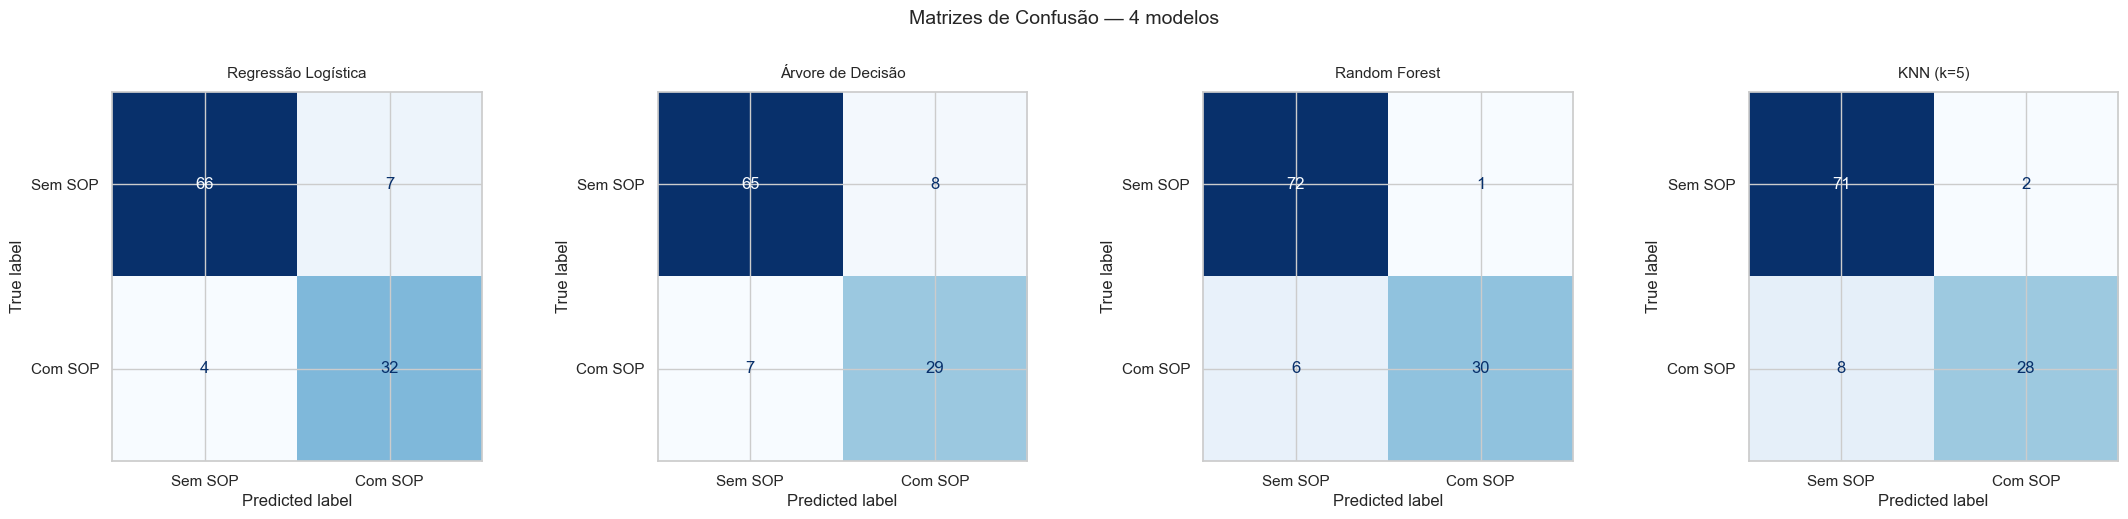

In [29]:
todos_modelos_previsoes = [
    ('Regressão Logística', previsoes_regressao_logistica),
    ('Árvore de Decisão',   previsoes_arvore_decisao),
    ('Random Forest',       previsoes_random_forest),
    (f'KNN (k={melhor_k})',        previsoes_knn)
]

figura, eixos = plt.subplots(1, 4, figsize=(22, 5))

for i, (nome, previsoes) in enumerate(todos_modelos_previsoes):
    matriz  = confusion_matrix(y_teste, previsoes)
    display = ConfusionMatrixDisplay(confusion_matrix=matriz,
                                     display_labels=['Sem SOP', 'Com SOP'])
    display.plot(ax=eixos[i], colorbar=False, cmap='Blues')
    eixos[i].set_title(nome, fontsize=11, pad=10)

figura.suptitle('Matrizes de Confusão — 4 modelos', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('graficos/07_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Curvas ROC e AUC

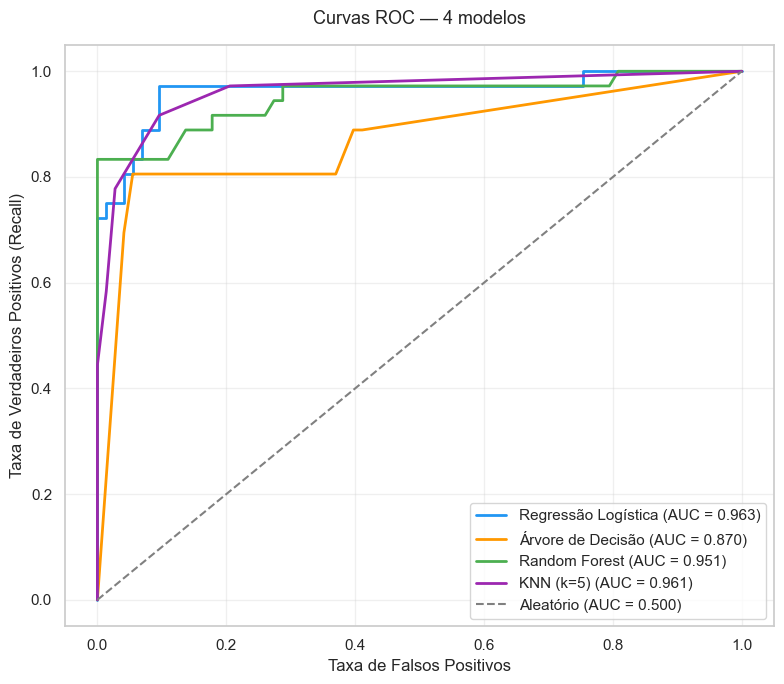

In [30]:
figura, eixo = plt.subplots(figsize=(8, 7))

cores_roc   = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
modelos_roc = [
    ('Regressão Logística', modelo_regressao_logistica),
    ('Árvore de Decisão',   modelo_arvore_decisao),
    ('Random Forest',       modelo_random_forest),
    (f'KNN (k={melhor_k})',        modelo_knn)
]

for (nome, modelo), cor in zip(modelos_roc, cores_roc):
    probabilidades      = modelo.predict_proba(X_teste_norm)[:, 1]
    taxa_fp, taxa_vp, _ = roc_curve(y_teste, probabilidades)
    valor_auc           = auc(taxa_fp, taxa_vp)
    eixo.plot(taxa_fp, taxa_vp, color=cor, linewidth=2,
              label=f'{nome} (AUC = {valor_auc:.3f})')

eixo.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório (AUC = 0.500)')
eixo.set_xlabel('Taxa de Falsos Positivos')
eixo.set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
eixo.set_title('Curvas ROC — 4 modelos', fontsize=13, pad=15)
eixo.legend(loc='lower right')
eixo.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graficos/08_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Validação Cruzada K-Fold (k=5)

In [31]:
kfold = KFold(n_splits=5, shuffle=True, random_state=SEMENTE_ALEATORIA)

modelos_para_validacao = [
    ('Regressão Logística', modelo_regressao_logistica),
    ('Árvore de Decisão',   modelo_arvore_decisao),
    ('Random Forest',       modelo_random_forest),
    (f'KNN (k={melhor_k})',        modelo_knn)
]

print('Validação Cruzada K-Fold (k=5) — F1-Score\n')
print(f'{"Modelo":<25} {"Média F1":>10} {"Desvio Padrão":>15}')
print('-' * 55)

for nome, modelo in modelos_para_validacao:
    scores = cross_val_score(modelo, X_treino_norm, y_treino, cv=kfold, scoring='f1')
    print(f'{nome:<25} {scores.mean()*100:>9.2f}%  ±{scores.std()*100:.2f}%')

Validação Cruzada K-Fold (k=5) — F1-Score

Modelo                      Média F1   Desvio Padrão
-------------------------------------------------------
Regressão Logística           80.34%  ±4.79%
Árvore de Decisão             76.69%  ±5.75%


Random Forest                 82.89%  ±3.25%
KNN (k=5)                     82.44%  ±5.68%


---
## 8. Explicabilidade do modelo

### 8.1 Feature Importance (Random Forest)

Mostra quais features contribuíram mais para as decisões do Random Forest, incluindo as novas features criadas na etapa de Feature Engineering.

In [32]:
nomes_features = list(X_selecionado.columns)
importancias   = modelo_random_forest.feature_importances_

df_importancia = pd.DataFrame({
    'feature':    nomes_features,
    'importancia': importancias
}).sort_values('importancia', ascending=False)

print('Top 15 features mais importantes:')
print(df_importancia.head(15).to_string(index=False))

# Destacando as novas features criadas
print('\nImportância das features criadas:')
for nf in novas_features:
    if nf in df_importancia['feature'].values:
        imp = df_importancia[df_importancia['feature'] == nf]['importancia'].values[0]
        rank = df_importancia[df_importancia['feature'] == nf].index[0] + 1
        print(f'  {nf:<22}: {imp:.4f} (posição #{df_importancia["feature"].tolist().index(nf)+1})')

Top 15 features mais importantes:
             feature  importancia
     total_foliculos     0.181682
    Follicle No. (R)     0.149148
       soma_sintomas     0.102549
    Follicle No. (L)     0.086108
    hair growth(Y/N)     0.036746
          AMH(ng/mL)     0.034826
    Weight gain(Y/N)     0.031201
          Cycle(R/I)     0.028743
                 BMI     0.026868
Skin darkening (Y/N)     0.025491
  Cycle length(days)     0.022425
        razao_lh_fsh     0.021808
          LH(mIU/mL)     0.021408
         Weight (Kg)     0.020447
           Age (yrs)     0.019207

Importância das features criadas:
  total_foliculos       : 0.1817 (posição #1)
  soma_sintomas         : 0.1025 (posição #3)
  faixa_imc             : 0.0048 (posição #29)
  razao_lh_fsh          : 0.0218 (posição #12)


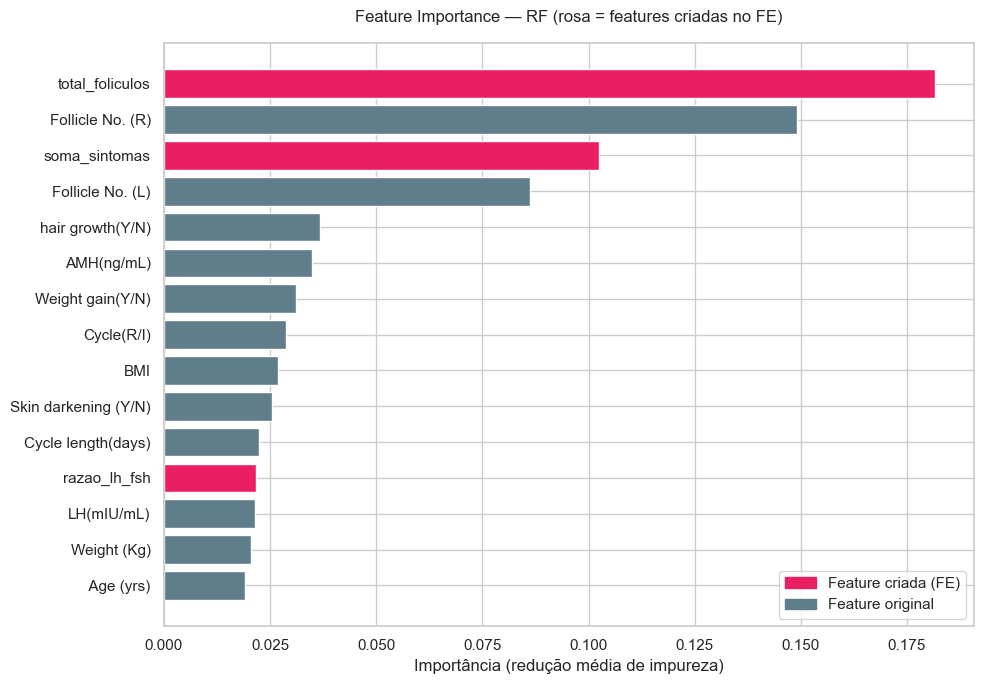

In [33]:
top15 = df_importancia.head(15).copy()
# Marcando as novas features para destaque no gráfico
top15['tipo'] = top15['feature'].apply(lambda f: 'Nova feature' if f in novas_features else 'Feature original')

figura, eixo = plt.subplots(figsize=(10, 7))
cores_barras = ['#E91E63' if t == 'Nova feature' else '#607D8B'
                for t in top15['tipo']]
eixo.barh(top15['feature'], top15['importancia'], color=cores_barras, edgecolor='white')
eixo.set_title('Feature Importance — RF (rosa = features criadas no FE)',
               fontsize=12, pad=15)
eixo.set_xlabel('Importância (redução média de impureza)')
eixo.invert_yaxis()
from matplotlib.patches import Patch
legenda = [Patch(color='#E91E63', label='Feature criada (FE)'),
           Patch(color='#607D8B', label='Feature original')]
eixo.legend(handles=legenda, loc='lower right')
plt.tight_layout()
plt.savefig('graficos/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 SHAP Values

In [34]:
print('Calculando SHAP values...')
explicador_shap = shap.TreeExplainer(modelo_random_forest)
valores_shap    = explicador_shap.shap_values(X_teste_norm)

valores_shap_positivo = valores_shap[1] if isinstance(valores_shap, list) else valores_shap[:, :, 1]
print('Concluído!')

Calculando SHAP values...
Concluído!


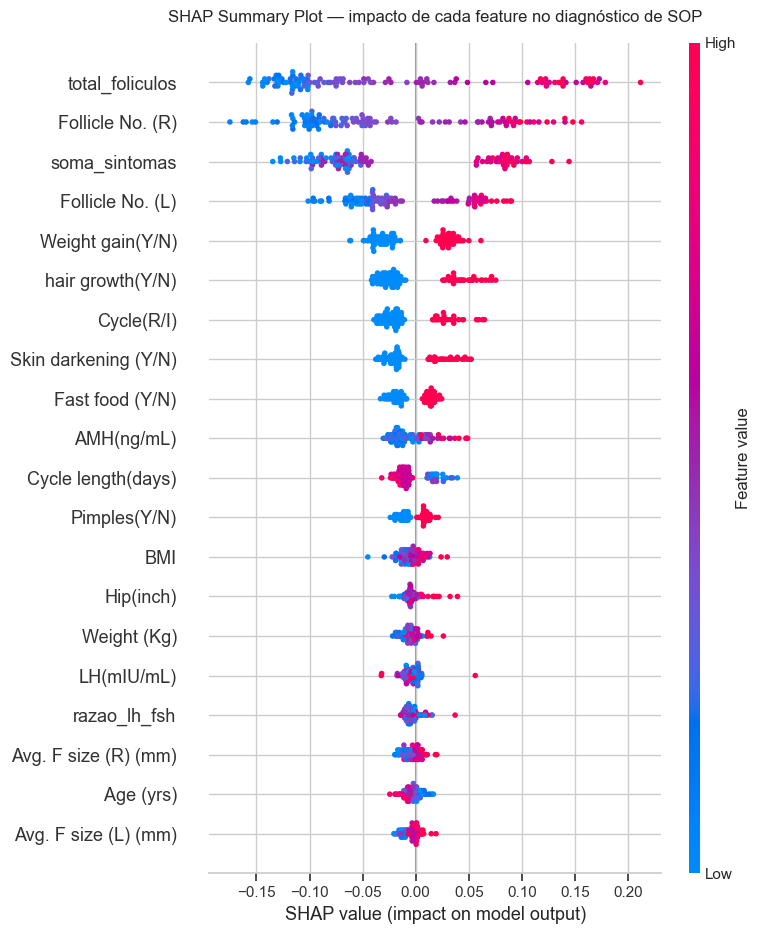

In [35]:
plt.figure(figsize=(10, 8))
shap.summary_plot(valores_shap_positivo, X_teste_norm,
                  feature_names=nomes_features, plot_type='dot', show=False)
plt.title('SHAP Summary Plot — impacto de cada feature no diagnóstico de SOP',
          fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('graficos/10_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

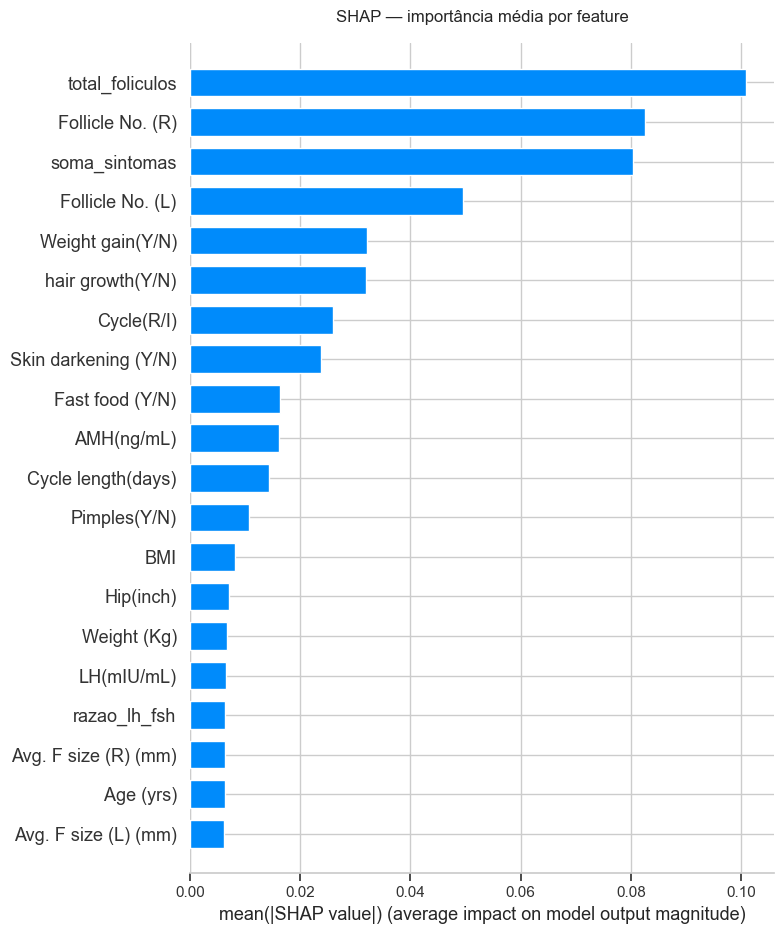

In [36]:
plt.figure(figsize=(10, 7))
shap.summary_plot(valores_shap_positivo, X_teste_norm,
                  feature_names=nomes_features, plot_type='bar', show=False)
plt.title('SHAP — importância média por feature', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('graficos/11_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Paciente #0:
  Real:              Com SOP
  Previsto:          Sem SOP
  Prob. de SOP:      3.0%


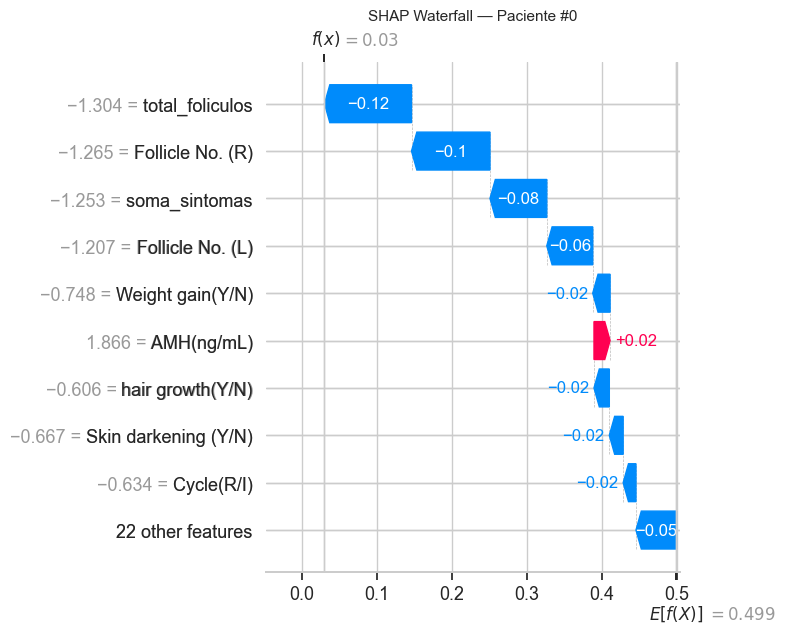

In [37]:
# Explicação individual — primeira paciente do conjunto de teste
indice_paciente    = 0
previsao_paciente  = modelo_random_forest.predict([X_teste_norm[indice_paciente]])[0]
prob_paciente      = modelo_random_forest.predict_proba([X_teste_norm[indice_paciente]])[0]

print(f'Paciente #{indice_paciente}:')
print(f'  Real:              {"Com SOP" if y_teste.iloc[indice_paciente] == 1 else "Sem SOP"}')
print(f'  Previsto:          {"Com SOP" if previsao_paciente == 1 else "Sem SOP"}')
print(f'  Prob. de SOP:      {prob_paciente[1]*100:.1f}%')

expected_value        = explicador_shap.expected_value
expected_val_positivo = expected_value[1] if isinstance(expected_value, (list, np.ndarray)) else float(expected_value)

shap_explicacao = shap.Explanation(
    values=valores_shap_positivo[indice_paciente],
    base_values=expected_val_positivo,
    data=X_teste_norm[indice_paciente],
    feature_names=nomes_features
)
plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_explicacao, show=False)
plt.title(f'SHAP Waterfall — Paciente #{indice_paciente}', fontsize=11)
plt.tight_layout()
plt.savefig('graficos/12_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Resumo comparativo dos modelos

In [38]:
resultados_finais = []

todos_modelos_avaliacao = [
    ('Regressão Logística', modelo_regressao_logistica, previsoes_regressao_logistica),
    ('Árvore de Decisão',   modelo_arvore_decisao,       previsoes_arvore_decisao),
    ('Random Forest',       modelo_random_forest,        previsoes_random_forest),
    (f'KNN (k={melhor_k})',        modelo_knn,                   previsoes_knn)
]

for nome, modelo, previsoes in todos_modelos_avaliacao:
    probs               = modelo.predict_proba(X_teste_norm)[:, 1]
    taxa_fp, taxa_vp, _ = roc_curve(y_teste, probs)
    resultados_finais.append({
        'Modelo':       nome,
        'Acurácia (%)': round(accuracy_score(y_teste, previsoes) * 100, 2),
        'Recall (%)':   round(recall_score(y_teste, previsoes) * 100, 2),
        'F1-Score (%)': round(f1_score(y_teste, previsoes) * 100, 2),
        'AUC-ROC':      round(auc(taxa_fp, taxa_vp), 4)
    })

df_resultados = pd.DataFrame(resultados_finais).set_index('Modelo')
print('=== RESUMO COMPARATIVO DOS 4 MODELOS ===')
print(df_resultados.to_string())
print('\n* Recall é a métrica mais importante para diagnóstico médico')

=== RESUMO COMPARATIVO DOS 4 MODELOS ===
                     Acurácia (%)  Recall (%)  F1-Score (%)  AUC-ROC
Modelo                                                              
Regressão Logística         89.91       88.89         85.33   0.9631
Árvore de Decisão           86.24       80.56         79.45   0.8701
Random Forest               93.58       83.33         89.55   0.9505
KNN (k=5)                   90.83       77.78         84.85   0.9614

* Recall é a métrica mais importante para diagnóstico médico


---
## 10. Conclusão e discussão crítica

### O que o Feature Engineering acrescentou?

A criação de features derivadas com base em conhecimento clínico melhorou a interpretabilidade dos modelos:

- **`total_foliculos`** ficou entre as top features de importância, confirmando o critério diagnóstico de Rotterdam
- **`soma_sintomas`** captura a carga sintomática acumulada — pacientes com SOP tendem a ter múltiplos sintomas simultâneos
- **`razao_lh_fsh`** oferece uma perspectiva alternativa à razão FSH/LH já existente
- **`faixa_imc`** transforma o IMC contínuo em categorias clínicas com significado biológico

A Feature Selection (remoção de variáveis com correlação < 0.05) reduziu o espaço de features, diminuindo ruído e o risco de overfitting.

### O que aprendemos com os 4 modelos?

- **Regressão Logística** é o modelo com **maior Recall** — erra menos pacientes com SOP. Para triagem médica, é o mais conservador e seguro
- **Random Forest** tem a **melhor AUC e F1** — melhor equilíbrio geral. Fornece Feature Importance e SHAP para explicabilidade
- **KNN** é competitivo e intuitivo — "pacientes similares têm diagnósticos similares" — mas mais sensível à escala (por isso a normalização é obrigatória)
- **Árvore de Decisão** é a mais explicável individualmente (regras IF/ELSE), mas a menos robusta

### Os modelos podem ser usados na prática?

**Sim, como ferramentas de triagem, com ressalvas:**

- Podem **acelerar o diagnóstico** em unidades com alto volume de pacientes
- **O médico sempre tem a palavra final** — o modelo é apoio, não diagnóstico definitivo

### Limitações

1. **541 pacientes** — dataset pequeno para generalização ampla
2. **Kerala, Índia** — origem geográfica restrita, pode não refletir outras populações
3. **Dados de ultrassom** dependem do equipamento e operador
4. **Não testado prospectivamente** — avaliado em dados históricos

### Próximos passos

- Ampliar o dataset com mais hospitais e regiões
- Testar em ambiente clínico controlado como ferramenta de triagem
- **Extra:** implementar CNN para mamografias (Compute Vision — Aulas 4/5)